## Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import numpy as np

In [2]:
# styling for plots
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
print("Loading dataset from HuggingFace...")
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")
df = pd.DataFrame(dataset)
print(f"Dataset Shape: {df.shape}")
display(df.head(3))

Loading dataset from HuggingFace...


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Dataset Shape: (26872, 5)


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [4]:
sample = df.sample(1)
for _, row in sample.iterrows():
    print(f"instruction:{row['instruction']}\n")
    print(f"category:{row['category']}\n")
    print(f"intent:{row['intent']}\n")
    print(f"response:{row['response']}")


instruction:i want inofrmation about delivery periods how could i get it

category:DELIVERY

intent:delivery_period

response:We appreciate your interest in obtaining information about delivery periods. To provide you with accurate details, could you please provide us with the {{Tracking Number}} or {{Order Number}}? Once we have that information, we will be able to give you specific and up-to-date information about the estimated delivery period. Thank you for your patience and cooperation!


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [6]:
df.describe()

,flags,instruction,category,intent,response
count,26872,26872,26872,26872,26872
unique,394,24635,11,27,26870
top,BL,shiping to {{Delivery City}},ACCOUNT,contact_customer_service,"Firstly, I truly understand how pivotal the {{..."
freq,5212,8,5986,1000,2


In [7]:
df["intent"].value_counts()

,count
intent,
contact_customer_service,1000
complaint,1000
check_invoice,1000
switch_account,1000
edit_account,1000
contact_human_agent,999
check_payment_methods,999
delivery_period,999
newsletter_subscription,999


In [8]:
df["category"].value_counts()

,count
category,
ACCOUNT,5986
ORDER,3988
REFUND,2992
CONTACT,1999
INVOICE,1999
PAYMENT,1998
FEEDBACK,1997
DELIVERY,1994
SHIPPING,1970


##  Check Missing Values


In [9]:
missing_data = df.isnull().sum()
print("\nMissing Values per Column:")
print(f"{missing_data} ")


Missing Values per Column:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64 


## Category And Intent

/tmp/ipykernel_4216/2977667121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[0], palette="Blues_d")
/tmp/ipykernel_4216/2977667121.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=intent_counts.values, y=intent_counts.index, ax=axes[1], palette="mako")


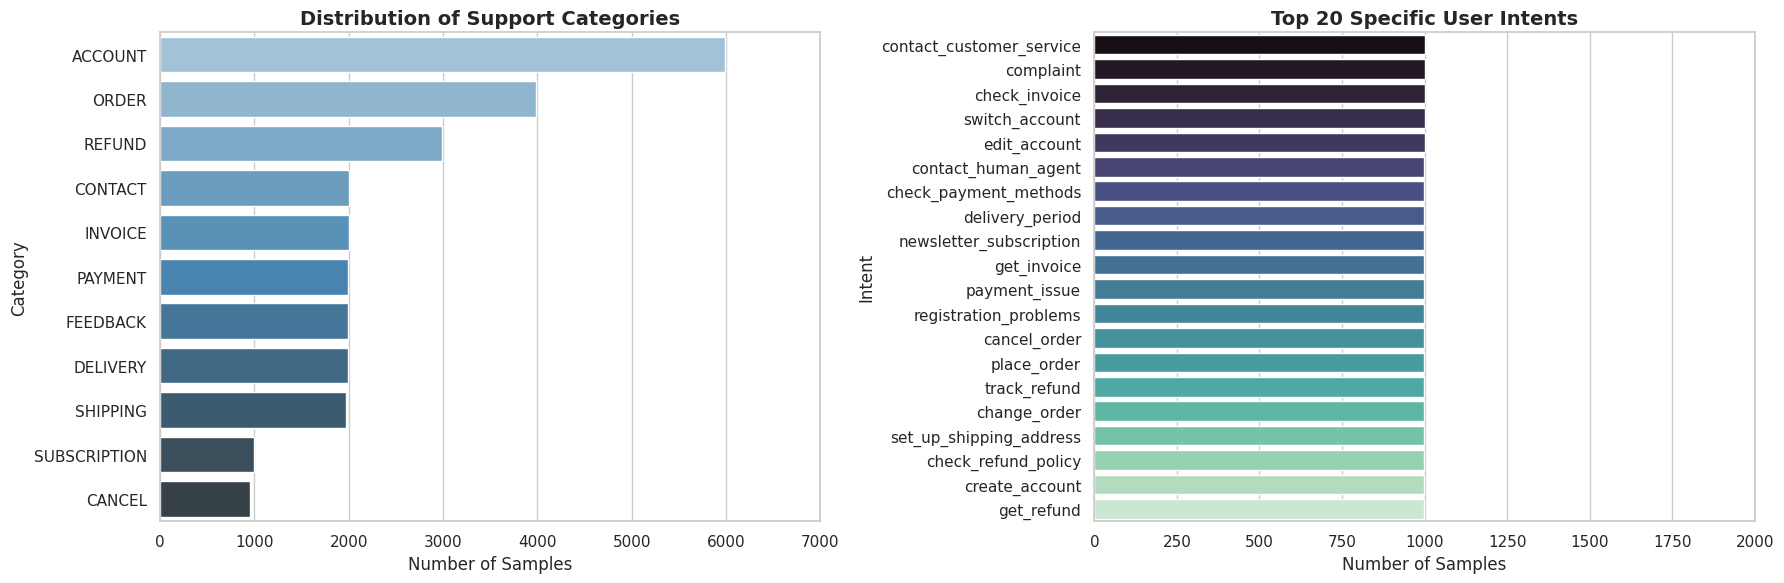

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Broad Categories
category_counts = df['category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[0], palette="Blues_d")
axes[0].set_title("Distribution of Support Categories", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Number of Samples")
axes[0].set_ylabel("Category")
axes[0].set_xlim(0,7000)
# Top 20 Specific Intents
intent_counts = df['intent'].value_counts().head(20)
sns.barplot(x=intent_counts.values, y=intent_counts.index, ax=axes[1], palette="mako")
axes[1].set_title("Top 20 Specific User Intents", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Number of Samples")
axes[1].set_ylabel("Intent")


axes[1].set_xlim(0,2000)


plt.tight_layout()
plt.show()


In [11]:
print(f"Total unique categories: {df['category'].nunique()}")
print(f"Total unique intents: {df['intent'].nunique()}")

Total unique categories: 11
Total unique intents: 27


## Token Distribution

In [12]:
# Approximate tokens (1 word ≈ 1.3 sub-word tokens)
df['instruction_tokens'] = df['instruction'].apply(lambda x: len(str(x).split()) * 1.3)
df['response_tokens'] = df['response'].apply(lambda x: len(str(x).split()) * 1.3)

# The total sequence length is what goes into the model (Prompt + Context + Response)
# We add ~40 tokens to account for our ChatML system prompt framing.
df['total_sequence_tokens'] = df['instruction_tokens'] + df['response_tokens'] + 40
df[['instruction_tokens','response_tokens','total_sequence_tokens']].describe()

,instruction_tokens,response_tokens,total_sequence_tokens
count,26872.000000,26872.000000,26872.000000
mean,11.298273,136.225748,187.524021
std,3.386506,68.856065,69.421581
min,1.300000,11.700000,60.800000
25%,9.100000,93.600000,144.000000
50%,11.700000,117.000000,168.700000
75%,14.300000,161.200000,212.900000
max,20.800000,522.600000,576.900000


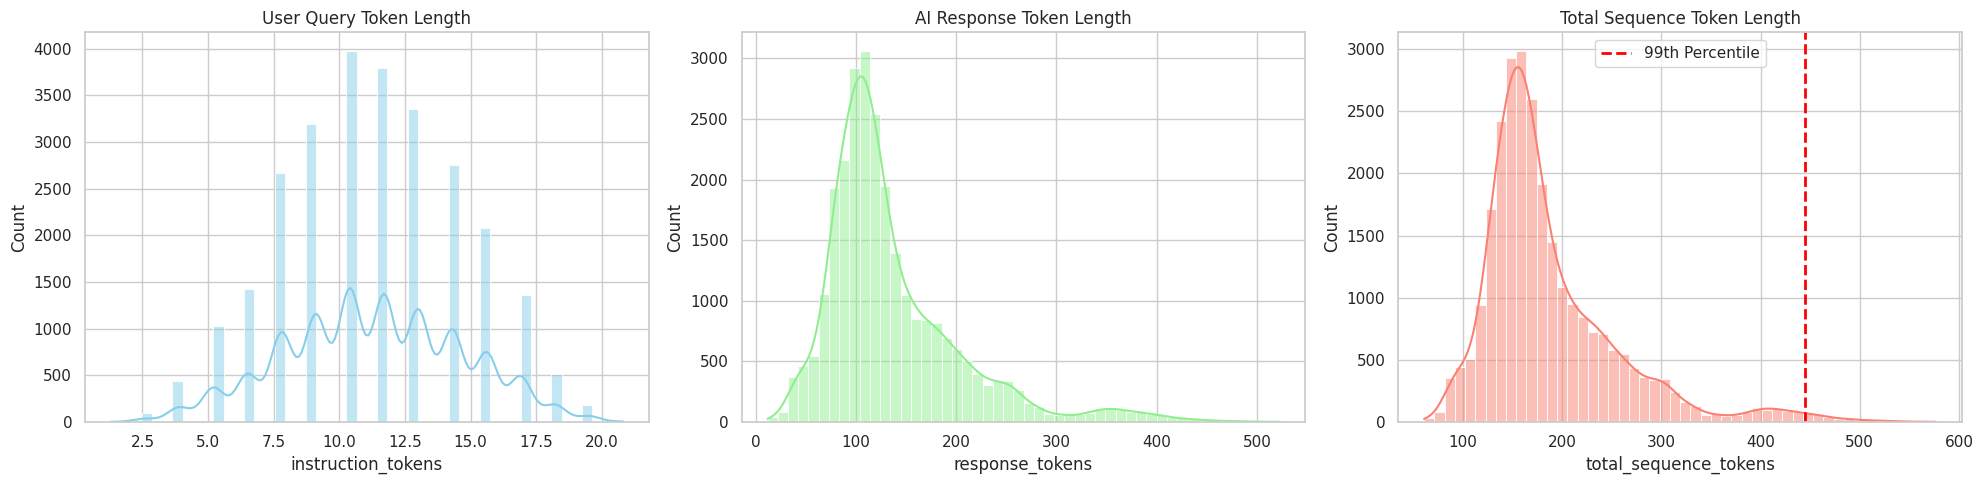

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(df['instruction_tokens'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title("User Query Token Length")

sns.histplot(df['response_tokens'], bins=50, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title("AI Response Token Length")

sns.histplot(df['total_sequence_tokens'], bins=50, ax=axes[2], color='salmon', kde=True)
axes[2].set_title("Total Sequence Token Length")
axes[2].axvline(df['total_sequence_tokens'].quantile(0.99), color='red', linestyle='dashed', linewidth=2, label='99th Percentile')
axes[2].legend()

plt.tight_layout()
plt.show()


In [14]:
p99_length = int(df['total_sequence_tokens'].quantile(0.99))
max_length = int(df['total_sequence_tokens'].max())

print(f"Average Total Tokens per sample: {int(df['total_sequence_tokens'].mean())}")
print(f"99% of all data falls under {p99_length} tokens.")
print(f"Absolute longest sequence is {max_length} tokens.")

Average Total Tokens per sample: 187
99% of all data falls under 444 tokens.
Absolute longest sequence is 576 tokens.
